# Weighted turbine power

This notebook shows the high-level API for wind farms where turbines do not all have the same nominal power. Pass `turbine_power` to `WindFarmNetwork`; cable capacities are interpreted in the same units. The first example goes directly from inputs to an optimized network. Later sections explain power scaling and compare the result with a uniform-power network.

Weighted turbine power is currently only a `MILPRouter` feature.

> `EWRouter` and `HGSRouter` currently assume unit-power turbines and reject non-uniform `turbine_power`.

In [1]:
import numpy as np
from optiwindnet.api import MILPRouter, WindFarmNetwork

In [2]:
# Display figures as SVG in Jupyter notebooks
%config InlineBackend.figure_formats = ['svg']

## Optimize a weighted network

Define the layout, cable catalogue, and nominal turbine powers, then solve the network with a MILP router.

In [3]:
turbinesC = np.array(
    [
        [0.0, 0.0],
        [1.0, 0.4],
        [2.0, 0.0],
        [0.3, 1.2],
        [1.3, 1.6],
        [2.4, 1.1],
    ]
)
substationsC = np.array([[1.2, -1.0]])
borderC = np.array(
    [
        [-0.5, -1.5],
        [3.0, -1.5],
        [3.0, 2.1],
        [-0.5, 2.1],
    ]
)

# Cable capacities and turbine powers use the same nominal units.
cables = [(2, 1.0), (3, 1.3), (4, 1.6)]
turbine_power = [1.0, 1.25, 1.0, 1.25, 1.5, 1.75]

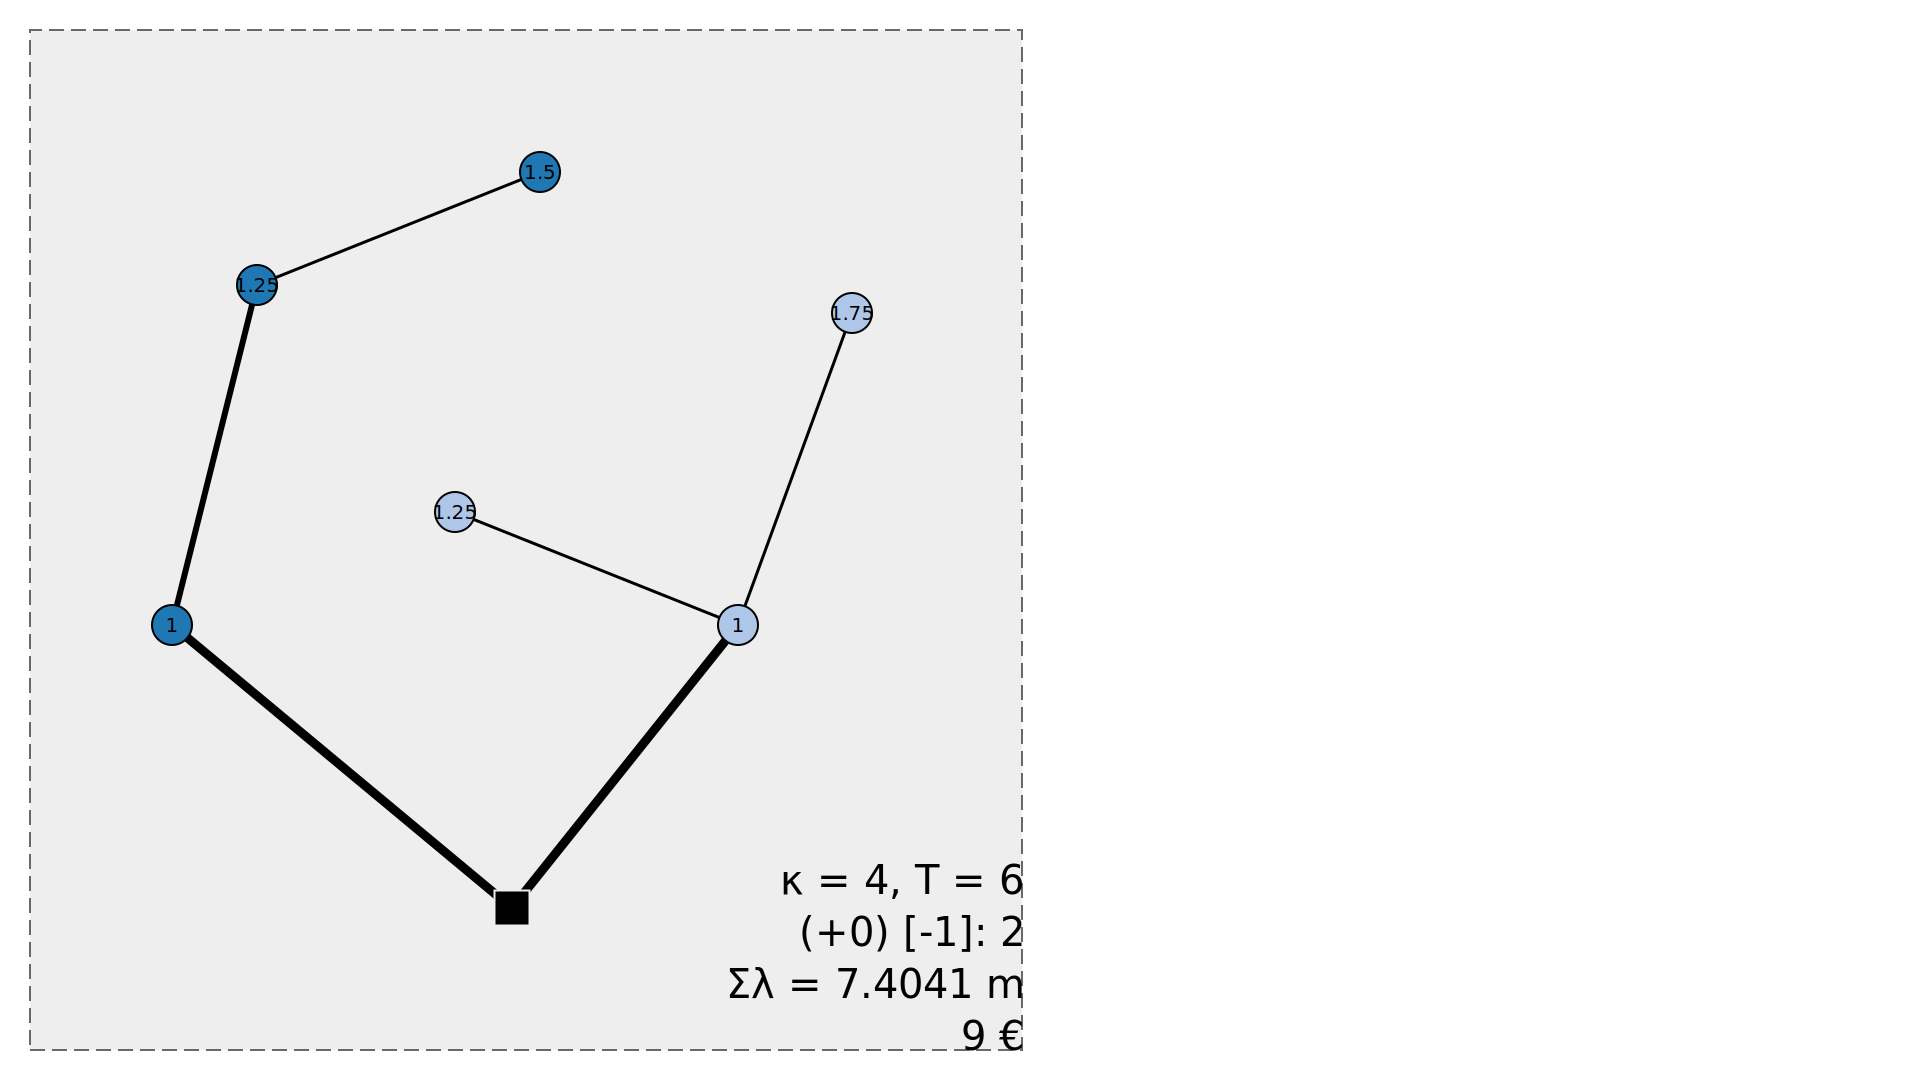

In [4]:
wfn = WindFarmNetwork(
    cables=cables,
    turbinesC=turbinesC,
    substationsC=substationsC,
    borderC=borderC,
    turbine_power=turbine_power,
    turbine_power_decimals=2,  # Default: 1.
)

solver_name = 'highs'  # Other backends include scip, gurobi, and cplex.
router = MILPRouter(solver_name=solver_name, time_limit=5, mip_gap=0.01)
wfn.optimize(router=router)

wfn.plot(node_tag='power')

### Plot and simple observations

In [5]:
print(f'Network cost: {wfn.cost():.3f}')
print(f'Network length: {wfn.length():.3f}')

print('Input turbine power:', turbine_power)
print(f'Power decimal places preserved: {wfn.turbine_power_decimals}')
print(f'Power scale: {wfn.power_scale}')
print('Rounded nominal power:', wfn.turbine_power)
print(
    'Integer power quanta:',
    [wfn.L.nodes[t]['power'] for t in range(len(turbine_power))],
)
print(f'Total nominal power: {sum(wfn.turbine_power):.2f}')

Network cost: 9.481
Network length: 7.404
Input turbine power: [1.0, 1.25, 1.0, 1.25, 1.5, 1.75]
Power decimal places preserved: 2
Power scale: 4
Rounded nominal power: [1.0, 1.25, 1.0, 1.25, 1.5, 1.75]
Integer power quanta: [4, 5, 4, 5, 6, 7]
Total nominal power: 7.75


## Power rounding and integer scale

`turbine_power_decimals` defaults to `1`. Increase it when smaller differences in turbine power should be preserved. Powers are first rounded to this precision, then OptiWindNet chooses the smallest `power_scale` that converts every rounded value to an integer quantum; it does not automatically use `10 ** turbine_power_decimals`. For example, `[1.0, 1.5, 2.0]` needs a scale of `2`, while `[1.0, 1.5, 1.6]` requires a scale of `10`. Internal power quanta equal nominal power multiplied by `power_scale`.

> Depending on the `turbine_power` reducing `turbine_power_decimals` might lead to higher power scaling, as it happens in the example of this notebook.

In [6]:
wfn_1d = WindFarmNetwork(
    cables=cables,
    turbinesC=turbinesC,
    substationsC=substationsC,
    borderC=borderC,
    turbine_power=turbine_power,
    turbine_power_decimals=1,  # Default: 1.
)

wfn_1d.optimize(router=router)

print('Input turbine power:', turbine_power)
print(f'Power decimal places preserved: {wfn_1d.turbine_power_decimals}')
print(f'Power scale: {wfn_1d.power_scale}')
print('Rounded nominal power:', wfn_1d.turbine_power)
print(
    'Integer power quanta:',
    [wfn_1d.L.nodes[t]['power'] for t in range(len(turbine_power))],
)
print(f'Total nominal power: {sum(wfn_1d.turbine_power):.2f}')

Input turbine power: [1.0, 1.25, 1.0, 1.25, 1.5, 1.75]
Power decimal places preserved: 1
Power scale: 10
Rounded nominal power: [1.0, 1.3, 1.0, 1.3, 1.5, 1.8]
Integer power quanta: [10, 13, 10, 13, 15, 18]
Total nominal power: 7.90


## Compare uniform and weighted power

The reference case uses the same coordinates, cable catalogue, solver, and solver settings, but omits `turbine_power` so every turbine has unit load.

In [7]:
wfn_uniform = WindFarmNetwork(
    cables=cables,
    turbinesC=turbinesC,
    substationsC=substationsC,
    borderC=borderC,
)

wfn_uniform.optimize(router=router)
print(f'Power scale: {wfn_uniform.power_scale}')

Power scale: 1


### Network layouts

The three cases (uniform turbine power and weighted turbine power with two different decimal precisions) are plotted side by side. The information boxes make the results easy to compare.

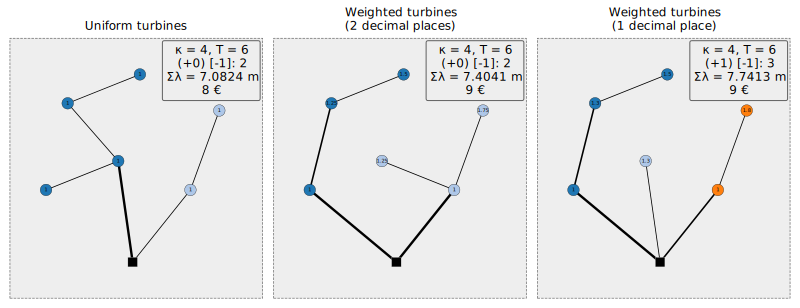

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(11, 5), constrained_layout=True)
wfn_uniform.plot(ax=axes[0], node_tag='power')
wfn.plot(ax=axes[1], node_tag='power')
wfn_1d.plot(ax=axes[2], node_tag='power')
axes[0].set_title('Uniform turbines')
axes[1].set_title('Weighted turbines\n(2 decimal places)')
axes[2].set_title('Weighted turbines\n(1 decimal place)')
plt.show()

### Numerical comparison

The table below reports the exact values behind the plot information boxes.

In [9]:
cases = [
    ('Uniform', wfn_uniform, len(turbine_power)),
    ('Weighted (2 decimal places)', wfn, sum(wfn.turbine_power)),
    ('Weighted (1 decimal place)', wfn_1d, sum(wfn_1d.turbine_power)),
]

print(
    f'{"Case":<30} {"Total power":>12} {"Scale":>7} '
    f'{"Feeders":>8} {"Length":>10} {"Cost":>10}'
)
print('-' * 83)
for label, network, total_power in cases:
    print(
        f'{label:<30} {total_power:>12.2f} {network.power_scale:>7} '
        f'{network.G.degree[-1]:>8} {network.length():>10.3f} '
        f'{network.cost():>10.3f}'
    )

Case                            Total power   Scale  Feeders     Length       Cost
-----------------------------------------------------------------------------------
Uniform                                6.00       1        2      7.082      7.931
Weighted (2 decimal places)            7.75       4        2      7.404      9.481
Weighted (1 decimal place)             7.90      10        3      7.741      9.434


> This feature can represent different fixed nominal generation capacities in a hybrid power plant, such as a project combining wind turbines, solar arrays, and other energy sources. It optimizes the cable network for the supplied nominal powers; it does not model time-varying generation or hybrid dispatch.